# 🌾 End-to-End Quantum Hybrid NN — Crop Yield Prediction

**Goal:** Prove that we can integrate a Quantum Neural Network (QNN) into a classical PyTorch pipeline to achieve state-of-the-art results for continuous crop yields.  
**Architecture:** We build a lightweight End-to-End model. The raw tabular features are passed into a Classical Pre-Layer, transformed into rotation angles, passed through a **7-qubit Variational Quantum Circuit (VQC)**, and finally the resulting quantum expectation values are fed directly into a small Classical Neural Network!  
**Data:** The same agricultural dataset, with identical categorical target encodings.

---
## Notebook Structure

| Step | Description |
|------|-------------|
| 1 | Load the dataset and apply target encodings |
| 2 | Initialize PennyLane & build the massive `EndToEndHybridQNN` architecture |
| 3 | Load the trained Quantum weights AND the trained Classical weights |
| 4 | Evaluate raw features through the full pipeline (R², MAE, RMSE) |
| 5 | Visualise Predictions vs Actuals |

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


---
## Step 1 — Load & Preprocess Data

In [2]:
df = pd.read_csv("crop_yield.csv")
df.drop(["Crop_Year", "Production"], axis=1, inplace=True)
for col in ["Crop", "Season", "State"]:
    df[col] = df[col].str.strip()

X = df.drop(columns=["Yield"])
y = np.log1p(df["Yield"].values)

X_train_df, X_temp_df, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val_df, X_test_df, y_val, y_test = train_test_split(X_temp_df, y_temp, test_size=0.50, random_state=SEED)

X_train_df = X_train_df.copy()
X_test_df  = X_test_df.copy()

global_mean = float(y_train.mean())
for col in ["Crop", "Season", "State"]:
    mean_map = pd.Series(y_train, index=X_train_df.index).groupby(X_train_df[col]).mean()
    X_train_df[col] = X_train_df[col].map(mean_map).fillna(global_mean)
    X_test_df[col]  = X_test_df[col].map(mean_map).fillna(global_mean)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_test  = scaler.transform(X_test_df).astype(np.float32)
y_test  = y_test.astype(np.float32)

test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test).unsqueeze(1)), batch_size=256)
print(f"Test set size: {X_test.shape}")

Test set size: (2954, 7)


---
## Step 2 — Rebuild the Full End-to-End Pipeline
We reconstruct the PennyLane VQC and link it directly to the small Classical Neural Network.

In [3]:
N_QUBITS = 7
N_LAYERS = 3

try:
    dev = qml.device("lightning.qubit", wires=N_QUBITS)
    is_lightning = True
except Exception:
    dev = qml.device("default.qubit", wires=N_QUBITS)
    is_lightning = False

@qml.qnode(dev, diff_method="adjoint" if is_lightning else "best", interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

class HybridQNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.pre = nn.Sequential(nn.Linear(N_QUBITS, N_QUBITS), nn.Tanh())
        self.qlayer = qlayer
        self.post = nn.Sequential(nn.Linear(N_QUBITS, 32), nn.SiLU(), nn.Linear(32, 1))

    def forward(self, x):
        x = self.pre(x) * torch.pi
        x = self.qlayer(x)
        return self.post(x)

model = HybridQNN().to(DEVICE)
print(f"End-to-End Model parameters: {sum(p.numel() for p in model.parameters()):,}")

End-to-End Model parameters: 408


---
## Step 3 — Load Weights
Load the weights of the trained lightweight Hybrid QNN.

In [4]:
ckpt = torch.load("results/crop_yield/crop_yield_qnn_model.pth", map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print("[INFO] All weights loaded successfully!")

[INFO] All weights loaded successfully!


---
## Step 4 — Run Full Pipeline & Evaluate
We pass the raw X_test features through the entire pipeline (Classical -> Quantum -> Small Classical). Note: This will take a few moments as we are simulating the quantum circuit on the fly!

In [5]:
from tqdm.notebook import tqdm

preds, trues = [], []
with torch.no_grad():
    for Xb, yb in tqdm(test_loader, desc="Processing Test Set"):
        preds.append(model(Xb.to(DEVICE)).cpu())
        trues.append(yb)

p = torch.cat(preds).numpy().ravel()
t = torch.cat(trues).numpy().ravel()

p_raw = np.expm1(p)
t_raw = np.expm1(t)

r2_log = r2_score(t, p)
r2_raw = r2_score(t_raw, p_raw)
mae    = mean_absolute_error(t_raw, p_raw)
rmse   = np.sqrt(mean_squared_error(t_raw, p_raw))

print(f"R² (log scale): {r2_log:.4f}")
print(f"R² (raw yield): {r2_raw:.4f}")
print(f"MAE: {mae:.2f} t/ha")
print(f"RMSE: {rmse:.2f} t/ha")

Processing Test Set:   0%|          | 0/12 [00:00<?, ?it/s]

R² (log scale): 0.8734
R² (raw yield): 0.6322
MAE: 42.36 t/ha
RMSE: 556.21 t/ha


---
## Step 5 — Visualisation
Plotting the Quantum Model's predictions against the actual ground truth yields.

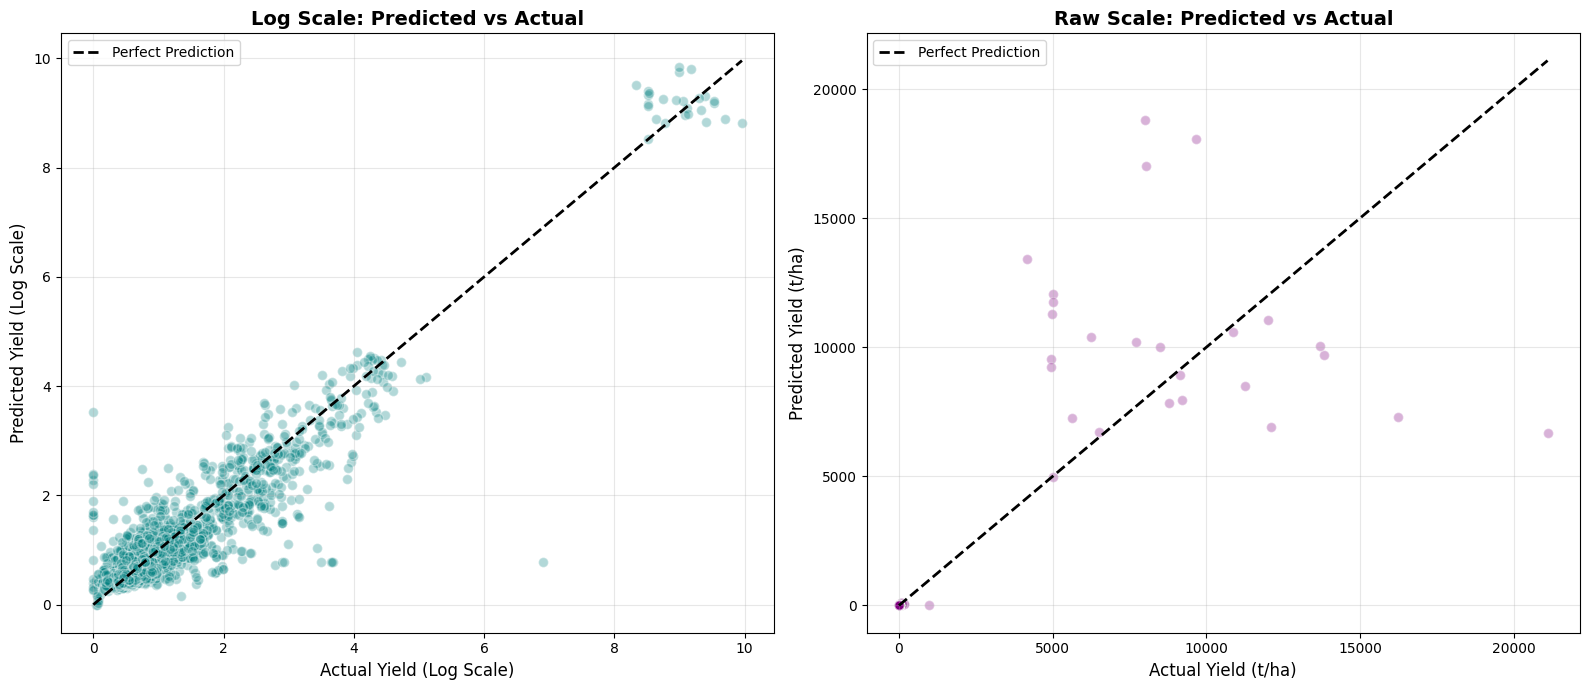

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Log Scale (What the model actually learned)
axes[0].scatter(t, p, alpha=0.3, color='teal', edgecolors='white', s=50)
axes[0].plot([0, max(t)], [0, max(t)], 'k--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Yield (Log Scale)', fontsize=12)
axes[0].set_ylabel('Predicted Yield (Log Scale)', fontsize=12)
axes[0].set_title('Log Scale: Predicted vs Actual', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Raw Scale
axes[1].scatter(t_raw, p_raw, alpha=0.3, color='purple', edgecolors='white', s=50)
axes[1].plot([0, max(t_raw)], [0, max(t_raw)], 'k--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Yield (t/ha)', fontsize=12)
axes[1].set_ylabel('Predicted Yield (t/ha)', fontsize=12)
axes[1].set_title('Raw Scale: Predicted vs Actual', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/crop_yield/qnn_end_to_end_pred_vs_actual.png', dpi=150)
plt.show()